In [1]:
import numpy as np

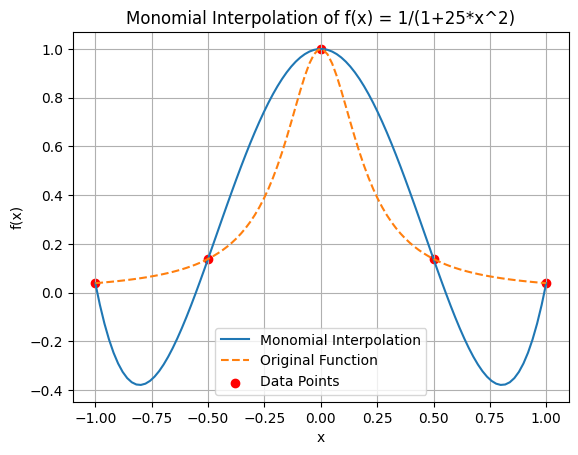

In [19]:
# Interpolation with monomial basis
def monomial_interpolation(x_values, y_values, x):
    k = len(x_values)
    # Create vandermonde matrix
    V = np.zeros((k, k))
    for i in range(k):
        for j in range(k):
            V[i, j] = x_values[i] ** j
    
    Vinv = np.linalg.inv(V)

    c = Vinv @ y_values

    y = 0
    for i in range(k):
        y += c[i] * x**i
    return y

# Plot the interpolation of the function f(x) = 1/(1+25*x^2) using monomial basis
import matplotlib.pyplot as plt
def f(x):
    return 1 / (1 + 25 * x**2)

x_values = np.linspace(-1, 1, 5)
y_values = f(x_values)
x_interp = np.linspace(-1, 1, 100)
y_interp = [monomial_interpolation(x_values, y_values, xi) for xi in x_interp]
plt.plot(x_interp, y_interp, label='Monomial Interpolation')
plt.plot(x_interp, f(x_interp), label='Original Function', linestyle='dashed')
plt.scatter(x_values, y_values, color='red', label='Data Points')
plt.legend()
plt.title('Monomial Interpolation of f(x) = 1/(1+25*x^2)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid()
plt.show()

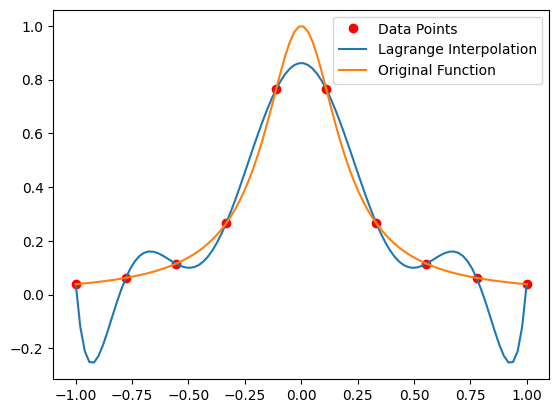

In [ ]:
# Lagrange

def L(k, x_vals, x):
    lnk = 1
    for i in range(len(x_vals)):
        if i != k:
            lnk *= (x - x_vals[i])/(x_vals[k] - x_vals[i])
    return lnk

def lagrange_interp( x_vals, y_vals, x):

    return sum([ y_vals[i] * L(i, x_vals, x) for i in range(len(x_vals)) ])

# Plot the Lagrange interpolation of the function f(x) = 1/(1+25*x^2) on the interval [-1, 1] using n equally spaced points.
import matplotlib.pyplot as plt
def f(x):
    return 1/(1+25*x**2)
n=10
x_vals = np.linspace(-1, 1, n)
y_vals = f(x_vals)
x_interp = np.linspace(-1, 1, 100)
y_interp = [lagrange_interp(x_vals, y_vals, x) for x in x_interp]
plt.plot(x_vals, y_vals, 'ro', label='Data Points')
plt.plot(x_interp, y_interp, label='Lagrange Interpolation')
plt.plot(x_interp, f(x_interp), label='Original Function')
plt.legend()
plt.show()

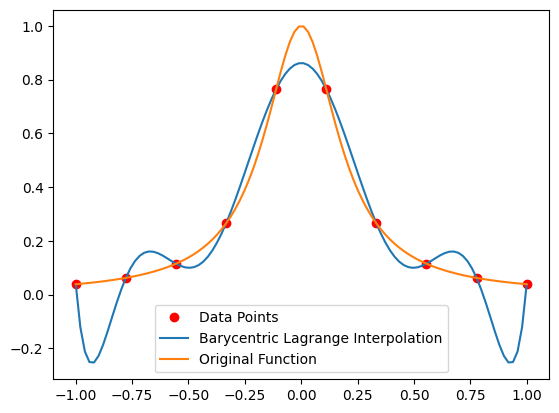

In [ ]:
# Barycentric Lagrange
def w(k, x_vals):
    prod = 1
    for i in range(len(x_vals)):
        if i != k:
            prod *= x_vals[k] - x_vals[i]
    return 1/prod

def barycentric_langrange(x_vals, y_vals, x):
    if x in x_vals:
        return y_vals[ np.where(x_vals == x)[0][0] ]

    wk = np.zeros(len(x_vals))
    for k in range(len(x_vals)):
        wk[k] = w(k, x_vals)

    return sum([ wk[k] / ( x - x_vals[k]) * y_vals[k] for k in range(len(x_vals)) ])/sum([ wk[k] / (x - x_vals[k]) for k in range(len(x_vals)) ])

# plot
x_vals = np.linspace(-1, 1, n)
y_vals = f(x_vals)
x_interp = np.linspace(-1, 1, 100)
y_interp_bary = [barycentric_langrange(x_vals, y_vals, x) for x in x_interp]

plt.plot(x_vals, y_vals, 'ro', label='Data Points')
plt.plot(x_interp, y_interp_bary, label='Barycentric Lagrange Interpolation')
plt.plot(x_interp, f(x_interp), label='Original Function')
plt.legend()
plt.show()

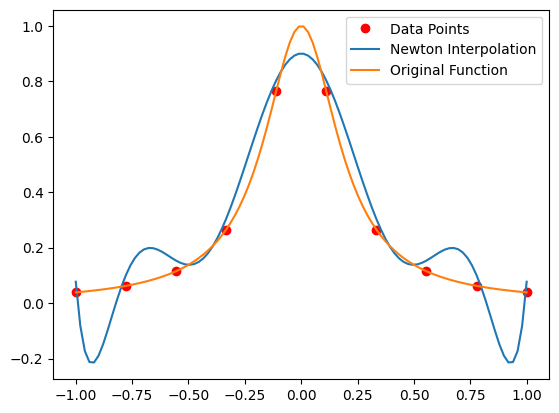

In [ ]:
# Newton divided differences

def newton_coeffs(n, x_vals, y_vals):
    F = np.zeros((n,n))
    F[:,0] = y_vals
    for j in range(1, n):
        for i in range(n-j): # j is the order of the divided difference, i is the index of the first point
            F[i][j] = (F[i+1][j-1] - F[i][j-1])/(x_vals[i+j] - x_vals[i])

    return F

def newton_interp(n, x_vals, y_vals, x):
    F = newton_coeffs(n, x_vals, y_vals)
    Pn = F[0][0]
    for i in range(n):
        term = F[0][i]
        for j in range(i):
            term *= (x - x_vals[j])
        Pn += term

    return Pn

# Plot the Newton interpolation of the function f(x) = 1/(1+25*x^2) on the interval [-1, 1] using n equally spaced points.
n=10
x_vals = np.linspace(-1, 1, n)
y_vals = f(x_vals)
x_interp = np.linspace(-1, 1, 100)
y_interp = [newton_interp(n, x_vals, y_vals, x) for x in x_interp]
plt.plot(x_vals, y_vals, 'ro', label='Data Points')
plt.plot(x_interp, y_interp, label='Newton Interpolation')
plt.plot(x_interp, f(x_interp), label='Original Function')
plt.legend()
plt.show()

In [ ]:
## Splines
